# Lógica difusa

Vamos a introducirnos en la lógica difusa (o borrosa). Vamos a construir sistemas de razonamiento basados en lógica difusa. Para ello, empezaremos a nivel teórico, planteando un problema paso a paso. Después veremos como implementar un problema difuso sencillo en Python. Y finalmente, implementamos un problema más complejo desde cero.

### ¿Cómo plantear un problema difuso?

Antes de nada, vamos a definir un problema:
Estas realizando una aplicación móvil al estilo Foursquare. Uno de los problemas que se encuentran los turistas cuando van a comer es que no saben que propina dar al restaurante.
Normalmente, se suele dar un porcentaje de la factura total, en función de ciertas variables que miden la satisfacción del cliente.


Pregunta: **¿Por qué es un problema difuso?**


PASO 1: **¿Cuáles podrían ser las variables?**

---


La pregunta anterior responde a las VARIABLES LINGÜÍSTICAS de entrada.
En este caso, parece lógico elegir el **servicio** del personal del restaurante, y la calidad de la **comida** que hemos comido.

Respecto a las VARIABLES LINGÜÍSTICAS de salida, en este caso solo deseamos saber el porcentaje de **propina** que tenemos que dar.

Ahora pensamos en los valores del UNIVERSO de cara variable. Normalmente, en las encuestas a cualquier cliente, la valoración más conocida es la numérica discreta de 0 a 10.
Respecto a la variable de salida, normalmente la propina va de 0% a 25%.

Por tanto, tenemos los valores discretos (crisp), y ahora queremos fuzzificar para pasar de discretos a difusos.

PASO 2: **¿Qué valores difusos podrían ser?**

# Fuzzificación

Vamos a poner, como ejemplo, los siguientes valores difusos:


*   Servicio: {deficiente, aceptable, increible}
*   Comida: {mala, decente, genial}
*   Propina: {tacaña, promedia, generosa}


Para fuzzificar, tenemos que elegir que funciones de pertenencia usaremos. Esta decisión es totalmente arbitraria, basada normalmente en la experiencia del experto. En este caso, tanto el servicio como la comida son valores discretos, provenientes de una encuesta, donde ningún cliente puede marcar un valor real, y la propina sería un valor real. Por simplicidad en el ejemplo, tomaremos funciones discretas simples.

**Servicio y comida**
En ambos casos vamos a usar las mismas funciones de pertenencia.
Vamos a considerar (decisión arbitraria o dada por el enunciado) que:


*   deficiente/mala: < 3
*   aceptable/decente: entre 3 y 7
*   increible/genial: > 7

Por lo tanto, vamos a usar 3 funciones de pertenencia triangulares. Para trazar los triángulos, tenemos que tener en cuenta la altura (la función de pertenencia tendrá máximo de 1), el núcleo o kernel, la punta del triángulo que es donde la función de pertenencia es 1 (coincide con los valores medio del soporte), y el soporte, que es la base del triángulo, y está formado por todo el rango donde existen valores cuya función de pertenencia es mayor que cero.

Empezamos con el rango medio: la punta del triángulo será el valor medio del rango ((3+7)/2 = 5), y su soporte será [1,9].
Rango bajo: cuando alguién califica como 0 un servicio o comida, es que se trata de su punto alto de insatisfacción (altura), por lo que situaremos la punta del triángulo en el 0, y el soporte, al llegar hasta el 3 en el conjunto, tendría un rango de valores de [-3,+3]. El rango negativo no entra dentro del universo, luego se recorta a [0,3].
Rango alto: de forma similar, situamos el máximo en 10 y el rango quedará en [7,10].

**Propina**
En este caso, el enunciado habla de una propina que, normalmente, está entre 0 y 25. Por lo tanto, suponemos que existe la posibilidad de que se dé más del 25%.
Teniendo esto en cuenta, usaremos una función de pertenencia triángular, y tomaremos como el rango medio (propina promedia) todo el rango de propinas [0,25] y la media como el máximo del triángulo (12.5%, que lo redondemos a 13% por simplicidad).


Respecto a las funciones, para propina sería triangular y para las otras gamma, L y PL.
**NOTA**: en un problema acotado, las tres pueden representarse como funciones triangulares. De hecho, en la librería que usamos abajo debe ser así.

Y las reglas a definir, serán las siguientes:

**R1**: SI servicio es increible O la comida es genial ENTONCES propina es generosa.

**R2**: SI servicio es aceptable ENTONCES propina es promedia.

**R3**: SI servicio es deficiente O la comida es mala ENTONCES propina es tacaña

# Mecanismo de inferencia

# Inferencia de Mamdani

Se utilizan reglas de inferencia difusa que establecen relaciones entre las entradas anteriores y las salidas. Esas entradas se aplican a los antecedentes de las reglas difusas y obtener el consecuente.

Si una regla tiene más de un antecedente, se utilizan los operadores para obtener un solo valor.
En el método de Mamdani, para obtener el valor Verdadero se hace uso de:


*   AND: min(fa,fb)
*   OR: max(fa,fb)


Se incluye un gráfico de los operadores:
<center width="100%" style="padding: 10px"><img src="https://es.mathworks.com/help/fuzzy/logic_graphs_2.png" width="600px"></center>

Por ejemplo, si el **antecedente** de la R3 dice "servicio deficiente OR comida mala", el valor resultado del antecedente sería el valor máximo de las dos funciones de pertenencia. Con ejemplos numéricos:


*   Si un cliente califica el servicio con un 10, y la comida con un 1, los valores de sus funciones de pertenencia serían:
    *   FservDeficiente(10) = 0 (con un 10 no puede pertenencer nunca al conjunto "servicio deficiente").
    *   FcomidaMala(2) = 0.7 (una calificación de 1 tiene un grado de pertenencia al conjunto "comida mala" del 0.3)
* Por tanto, nos quedamos con el valor max(0,0.7) = 0.7, que es el grado de verdad del antecedente de la regla R3.

Ese máximo va a ser el máximo del **consencuente**. Como ya hemos visto en la teoría, hay dos posibilidades de tratar al consecuente:


*   Recortado: simplemente recortamos la función de pertenencia del consecuente cuyo máximo será el valor obtenido anteriormente.
*   Escalado: se reescala toda la función de pertenencia con el nuevo máximo obtenido.

A continuación se puede ver otro ejemplo, de forma gráfica (no corresponde con ninguna de nuestras reglas).

<center width="100%" style="padding: 10px"><img src="https://es.mathworks.com/help/fuzzy/if-then_rules1_2.png" width="600px"></center>

Una vez se evaluan las tres reglas, se agregan todos los consecuentes para formar la función de pertenencia agregada.
Tras esto, falta el último paso.

# Defuzzificación

Una vez tenemos agregadas las funciones de pertenencia de todas las reglas, el último paso del modelo de Mamdani es la defuzzificación.

El valor final se obtiene mediante alguno de los métodos vistos, siendo el centroide el más común.

Ejemplo:
<center width="100%" style="padding: 10px"><img src="https://upload.wikimedia.org/wikipedia/commons/thumb/e/e3/Fuzzy_control_-_centroid_defuzzification_using_max-min_inferencing.png/1280px-Fuzzy_control_-_centroid_defuzzification_using_max-min_inferencing.png" width="600px"></center>

In [7]:
pip install scikit-fuzzy

Note: you may need to restart the kernel to use updated packages.


In [8]:
import numpy as np
import skfuzzy as fuzz
import matplotlib.pyplot as plt

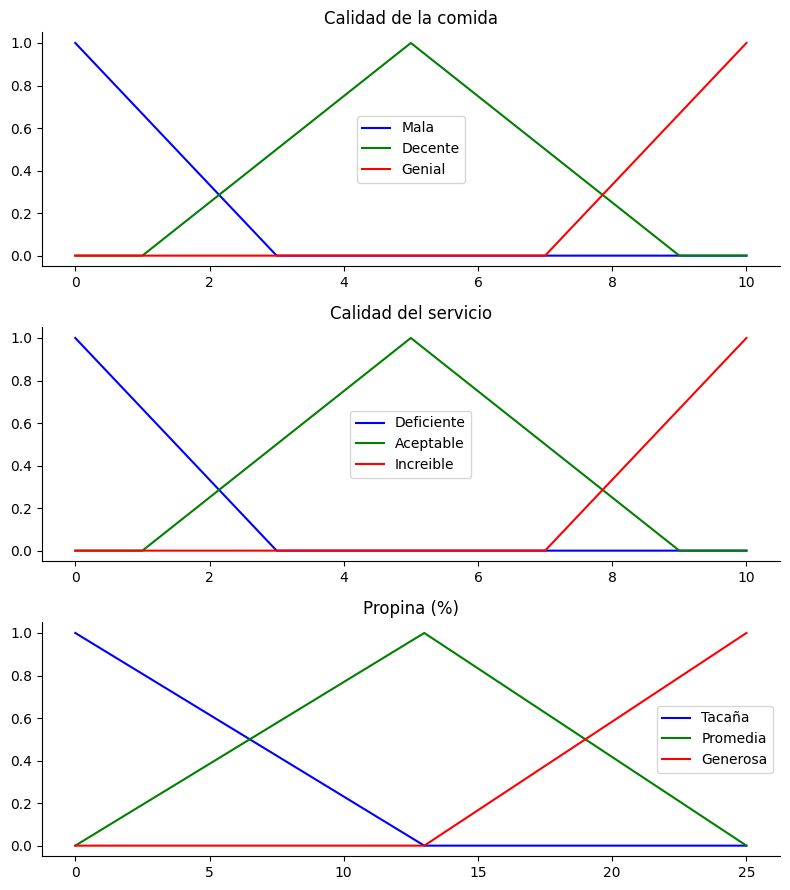

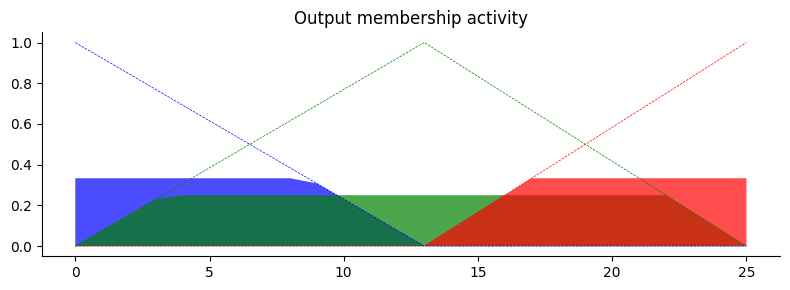

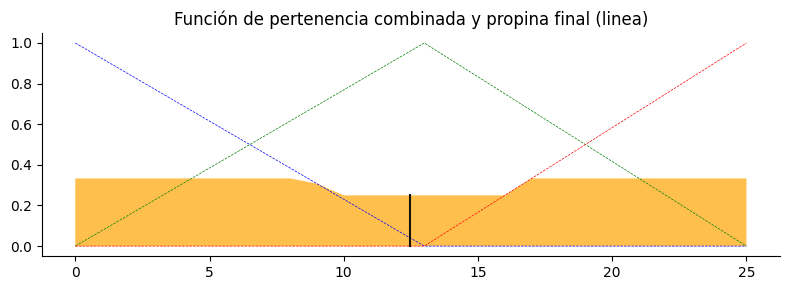

In [9]:
# Variables universales
  # Comida and Servicio están en el rango [0, 10]
  # Propina está en el rango [0, 25] en unidades porcentuales
x_comida = np.arange(0, 11, 1)
x_servicio = np.arange(0, 11, 1)
x_propina  = np.arange(0, 26, 1)

# Funciones de pertenencia difusas triangulares
mala = fuzz.trimf(x_comida, [0, 0, 3])
decente = fuzz.trimf(x_comida, [1, 5, 9])
genial = fuzz.trimf(x_comida, [7, 10, 10])
deficiente = fuzz.trimf(x_servicio, [0, 0, 3])
aceptable = fuzz.trimf(x_servicio, [1, 5, 9])
increible = fuzz.trimf(x_servicio, [7, 10, 10])
tacaña = fuzz.trimf(x_propina, [0, 0, 13])
promedia = fuzz.trimf(x_propina, [0, 13, 25])
generosa = fuzz.trimf(x_propina, [13, 25, 25])

# Visualización de los universos y las funciones de pertenencia
fig, (ax0, ax1, ax2) = plt.subplots(nrows=3, figsize=(8, 9))

ax0.plot(x_comida, mala, 'b', linewidth=1.5, label='Mala')
ax0.plot(x_comida, decente, 'g', linewidth=1.5, label='Decente')
ax0.plot(x_comida, genial, 'r', linewidth=1.5, label='Genial')
ax0.set_title('Calidad de la comida')
ax0.legend()

ax1.plot(x_servicio, deficiente, 'b', linewidth=1.5, label='Deficiente')
ax1.plot(x_servicio, aceptable, 'g', linewidth=1.5, label='Aceptable')
ax1.plot(x_servicio, increible, 'r', linewidth=1.5, label='Increible')
ax1.set_title('Calidad del servicio')
ax1.legend()

ax2.plot(x_propina, tacaña, 'b', linewidth=1.5, label='Tacaña')
ax2.plot(x_propina, promedia, 'g', linewidth=1.5, label='Promedia')
ax2.plot(x_propina, generosa, 'r', linewidth=1.5, label='Generosa')
ax2.set_title('Propina (%)')
ax2.legend()

for ax in (ax0, ax1, ax2):
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.get_xaxis().tick_bottom()
    ax.get_yaxis().tick_left()

plt.tight_layout()

"""

Reglas
-----------

Tenemos 3 reglas

R1: SI servicio es increible O la comida es genial ENTONCES propina es generosa.
R2: SI servicio es aceptable ENTONCES propina es promedia.
R3: SI servicio es deficiente O la comida es mala ENTONCES propina es tacaña



Valores de aplicación
----------------

Un cliente califica al restaurante con la puntuación p_comida (comida) y p_servicio (servicio)

"""

p_comida = 2
p_servicio = 8

# Con fuzz.interp_membership obtenemos el valor de la función de pertenencia para valores concretos de un cliente

comida_mala = fuzz.interp_membership(x_comida, mala, p_comida)
comida_decente = fuzz.interp_membership(x_comida, decente, p_comida)
comida_genial = fuzz.interp_membership(x_comida, genial, p_comida)

servicio_deficiente = fuzz.interp_membership(x_servicio, deficiente, p_servicio)
servicio_aceptable = fuzz.interp_membership(x_servicio, aceptable, p_servicio)
servicio_increible = fuzz.interp_membership(x_servicio, increible, p_servicio)

# Aplicación de las reglas
# Regla R1:  Servicio es increible O la comida es genial
# Con Mandani, el operador OR operator toma el máximo valor de los dos
aplicacion_R1 = np.fmax(servicio_increible, comida_genial)

# Ahora aplicamos un recorte del consecuente en función del mínimo valor con 'np.fmin'
activacion_propina_generosa = np.fmin(aplicacion_R1, generosa)

# Regla R2: Servicio es aceptable.
# El antecendente es simple, no compuesto. Por tanto, buscamos el recorte directamente
activacion_propina_promedia = np.fmin(servicio_aceptable, promedia)

# Regla R3: Servicio es deficiente O la comida es mala, con el consecuente Propina es tacaña
aplicacion_R3 = np.fmax(servicio_deficiente, comida_mala)
activacion_propina_tacaña = np.fmin(aplicacion_R3, tacaña)
sinPropina = np.zeros_like(x_propina) #propina cero

# Visualización de las funciones de pertenencia de las 3 reglas recortadas
fig, ax0 = plt.subplots(figsize=(8, 3))

ax0.fill_between(x_propina, sinPropina, activacion_propina_tacaña, facecolor='b', alpha=0.7)
ax0.plot(x_propina, tacaña, 'b', linewidth=0.5, linestyle='--', )
ax0.fill_between(x_propina, sinPropina, activacion_propina_promedia, facecolor='g', alpha=0.7)
ax0.plot(x_propina, promedia, 'g', linewidth=0.5, linestyle='--')
ax0.fill_between(x_propina, sinPropina, activacion_propina_generosa, facecolor='r', alpha=0.7)
ax0.plot(x_propina, generosa, 'r', linewidth=0.5, linestyle='--')
ax0.set_title('Output membership activity')

for ax in (ax0,):
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.get_xaxis().tick_bottom()
    ax.get_yaxis().tick_left()

plt.tight_layout()

"""
Agregación/Combinación de las reglas
------------------------------------------------
"""

agregacion = np.fmax(activacion_propina_tacaña, np.fmax(activacion_propina_promedia, activacion_propina_generosa))

"""
Defuzzification
---------------
Usaremos el centroide
-------------------------------------------------
"""

# Defuzzificación por centroide
propina_final = fuzz.defuzz(x_propina, agregacion, 'centroid') #Resultado final
f_propina = fuzz.interp_membership(x_propina, agregacion, propina_final)  #Solo para visualizarla, no es necesario

# Defuzzificación por centroide
propina_final = fuzz.defuzz(x_propina, agregacion, 'centroid') #Resultado final
f_propina = fuzz.interp_membership(x_propina, agregacion, propina_final)  #Solo para visualizarla, no es necesario

# Visualización de las funciones de pertenencia agregadas con el resultado final
fig, ax0 = plt.subplots(figsize=(8, 3))

ax0.plot(x_propina, tacaña, 'b', linewidth=0.5, linestyle='--', )
ax0.plot(x_propina, promedia, 'g', linewidth=0.5, linestyle='--')
ax0.plot(x_propina, generosa, 'r', linewidth=0.5, linestyle='--')
ax0.fill_between(x_propina, sinPropina, agregacion, facecolor='Orange', alpha=0.7)
ax0.plot([propina_final, propina_final], [0, f_propina], 'k', linewidth=1.5, alpha=0.9)
ax0.set_title('Función de pertenencia combinada y propina final (linea)')


for ax in (ax0,):
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.get_xaxis().tick_bottom()
    ax.get_yaxis().tick_left()

plt.tight_layout()

In [10]:
float(propina_final)

12.47385892116183

# **Ejercicio Opcional**: Modificar el problema siguiendo las siguientes pautas:


*   Añadir una nueva variable, factura, que se evaluará como {barato, normal, caro}, y que tendrá valores entre 10 y 80 euros.
*   Fuzzificar la variable, a criterio del experto, con funciones de pertenencia trapezoidales.
*   Modificar y/o añadir las siguientes reglas:
  * R1: SI servicio es increible O la comida es genial O la factura es barata ENTONCES propina es generosa.
  * R2: SI servicio es aceptable Y factura es normal ENTONCES propina es promedia.
  * R3: SI servicio es deficiente O la comida es mala ENTONCES propina es tacaña
  * R4: SI factura es cara ENTONCES propina es tacaña

* Cambiar la función de pertenencia del servicio al tipo S.
* Cambiar el método de defuzzificación a bisectriz, MOM, LOM y SOM, y comparar. el resultado que os sale, modificando los valores del cliente
* Cambiar al modelo TSK en lugar de Mamdani.
* Supon factura de 30€

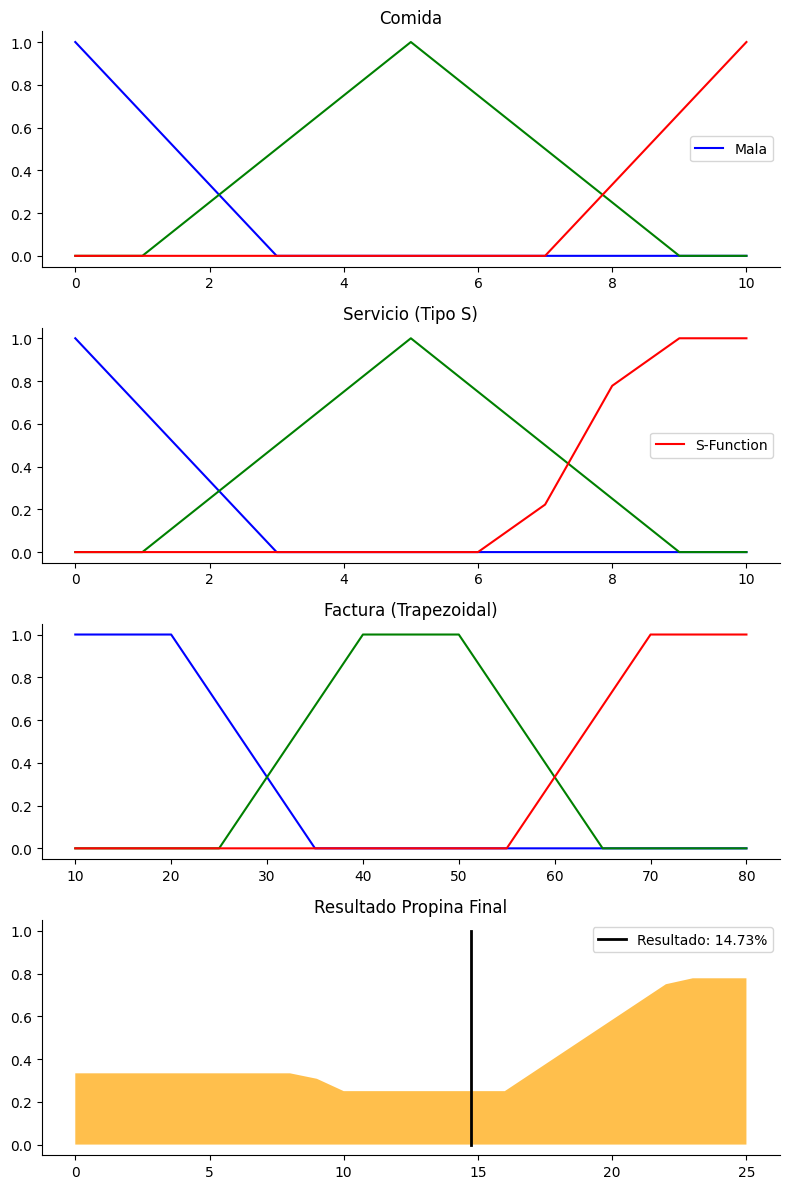

In [11]:
import numpy as np
import skfuzzy as fuzz
import matplotlib.pyplot as plt

# 1. Universos de discurso
x_comida = np.arange(0, 11, 1)
x_servicio = np.arange(0, 11, 1)
x_factura = np.arange(10, 81, 1) # Nueva variable: 10 a 80 euros
x_propina  = np.arange(0, 26, 1)

# 2. Funciones de pertenencia
# Comida (Triangulares)
mala = fuzz.trimf(x_comida, [0, 0, 3])
decente = fuzz.trimf(x_comida, [1, 5, 9])
genial = fuzz.trimf(x_comida, [7, 10, 10])

# Servicio (Cambiado a tipo S como pide el ejercicio)
deficiente = fuzz.trimf(x_servicio, [0, 0, 3])
aceptable = fuzz.trimf(x_servicio, [1, 5, 9])
increible = fuzz.smf(x_servicio, 6, 9) # Función S

# Factura (Nuevas: Trapezoidales)
barata = fuzz.trapmf(x_factura, [10, 10, 20, 35])
normal = fuzz.trapmf(x_factura, [25, 40, 50, 65])
caro   = fuzz.trapmf(x_factura, [55, 70, 80, 80])

# Propina (Consecuentes)
tacaña = fuzz.trimf(x_propina, [0, 0, 13])
promedia = fuzz.trimf(x_propina, [0, 13, 25])
generosa = fuzz.trimf(x_propina, [13, 25, 25])

# 3. Valores del cliente (Ejemplo)
p_comida = 2
p_servicio = 8
p_factura = 30 # Supongamos una factura de 30€

# 4. Fuzzificación
c_mala = fuzz.interp_membership(x_comida, mala, p_comida)
c_genial = fuzz.interp_membership(x_comida, genial, p_comida)
s_deficiente = fuzz.interp_membership(x_servicio, deficiente, p_servicio)
s_aceptable = fuzz.interp_membership(x_servicio, aceptable, p_servicio)
s_increible = fuzz.interp_membership(x_servicio, increible, p_servicio)
f_barata = fuzz.interp_membership(x_factura, barata, p_factura)
f_normal = fuzz.interp_membership(x_factura, normal, p_factura)
f_caro = fuzz.interp_membership(x_factura, caro, p_factura)

# 5. Aplicación de las nuevas reglas
# R1: SI servicio increible O comida genial O factura barata ENTONCES generosa
r1_val = np.fmax(s_increible, np.fmax(c_genial, f_barata))
act_generosa = np.fmin(r1_val, generosa)

# R2: SI servicio aceptable Y factura normal ENTONCES promedia
r2_val = np.fmin(s_aceptable, f_normal)
act_promedia = np.fmin(r2_val, promedia)

# R3: SI servicio deficiente O comida mala ENTONCES tacaña
r3_val = np.fmax(s_deficiente, c_mala)
act_tacaña_r3 = np.fmin(r3_val, tacaña)

# R4: SI factura cara ENTONCES tacaña
act_tacaña_r4 = np.fmin(f_caro, tacaña)

# Unimos las activaciones
act_tacaña = np.fmax(act_tacaña_r3, act_tacaña_r4)
agregacion = np.fmax(act_tacaña, np.fmax(act_promedia, act_generosa))

# 6. Defuzzificación (Cambiable según el ejercicio: 'centroid', 'bisector', 'mom', etc.)
propina_final = fuzz.defuzz(x_propina, agregacion, 'centroid')

# 7. Visualización
fig, (ax0, ax1, ax2, ax3) = plt.subplots(nrows=4, figsize=(8, 12))

ax0.plot(x_comida, mala, 'b', label='Mala'); ax0.plot(x_comida, decente, 'g'); ax0.plot(x_comida, genial, 'r')
ax0.set_title('Comida'); ax0.legend()

ax1.plot(x_servicio, deficiente, 'b'); ax1.plot(x_servicio, aceptable, 'g'); ax1.plot(x_servicio, increible, 'r', label='S-Function')
ax1.set_title('Servicio (Tipo S)'); ax1.legend()

ax2.plot(x_factura, barata, 'b'); ax2.plot(x_factura, normal, 'g'); ax2.plot(x_factura, caro, 'r')
ax2.set_title('Factura (Trapezoidal)')

ax3.fill_between(x_propina, np.zeros_like(x_propina), agregacion, facecolor='Orange', alpha=0.7)
ax3.plot([propina_final, propina_final], [0, 1], 'k', linewidth=2, label=f'Resultado: {propina_final:.2f}%')
ax3.set_title('Resultado Propina Final')
ax3.legend()

for ax in (ax0, ax1, ax2, ax3):
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.show()

In [12]:
float(propina_final)

14.729731638418075

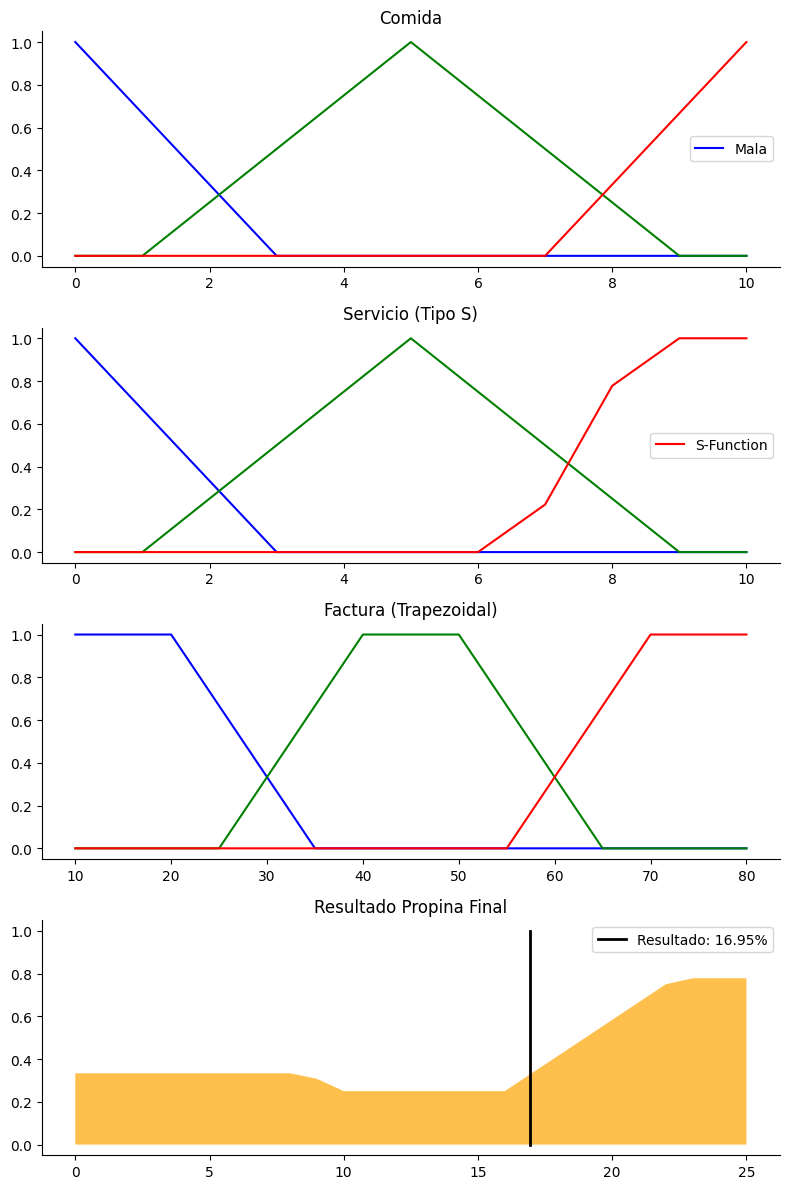

In [13]:
import numpy as np
import skfuzzy as fuzz
import matplotlib.pyplot as plt

# 1. Universos de discurso
x_comida = np.arange(0, 11, 1)
x_servicio = np.arange(0, 11, 1)
x_factura = np.arange(10, 81, 1) # Nueva variable: 10 a 80 euros
x_propina  = np.arange(0, 26, 1)

# 2. Funciones de pertenencia
# Comida (Triangulares)
mala = fuzz.trimf(x_comida, [0, 0, 3])
decente = fuzz.trimf(x_comida, [1, 5, 9])
genial = fuzz.trimf(x_comida, [7, 10, 10])

# Servicio (Cambiado a tipo S como pide el ejercicio)
deficiente = fuzz.trimf(x_servicio, [0, 0, 3])
aceptable = fuzz.trimf(x_servicio, [1, 5, 9])
increible = fuzz.smf(x_servicio, 6, 9) # Función S

# Factura (Nuevas: Trapezoidales)
barata = fuzz.trapmf(x_factura, [10, 10, 20, 35])
normal = fuzz.trapmf(x_factura, [25, 40, 50, 65])
caro   = fuzz.trapmf(x_factura, [55, 70, 80, 80])

# Propina (Consecuentes)
tacaña = fuzz.trimf(x_propina, [0, 0, 13])
promedia = fuzz.trimf(x_propina, [0, 13, 25])
generosa = fuzz.trimf(x_propina, [13, 25, 25])

# 3. Valores del cliente (Ejemplo)
p_comida = 2
p_servicio = 8
p_factura = 30 # Supongamos una factura de 30€

# 4. Fuzzificación
c_mala = fuzz.interp_membership(x_comida, mala, p_comida)
c_genial = fuzz.interp_membership(x_comida, genial, p_comida)
s_deficiente = fuzz.interp_membership(x_servicio, deficiente, p_servicio)
s_aceptable = fuzz.interp_membership(x_servicio, aceptable, p_servicio)
s_increible = fuzz.interp_membership(x_servicio, increible, p_servicio)
f_barata = fuzz.interp_membership(x_factura, barata, p_factura)
f_normal = fuzz.interp_membership(x_factura, normal, p_factura)
f_caro = fuzz.interp_membership(x_factura, caro, p_factura)

# 5. Aplicación de las nuevas reglas
# R1: SI servicio increible O comida genial O factura barata ENTONCES generosa
r1_val = np.fmax(s_increible, np.fmax(c_genial, f_barata))
act_generosa = np.fmin(r1_val, generosa)

# R2: SI servicio aceptable Y factura normal ENTONCES promedia
r2_val = np.fmin(s_aceptable, f_normal)
act_promedia = np.fmin(r2_val, promedia)

# R3: SI servicio deficiente O comida mala ENTONCES tacaña
r3_val = np.fmax(s_deficiente, c_mala)
act_tacaña_r3 = np.fmin(r3_val, tacaña)

# R4: SI factura cara ENTONCES tacaña
act_tacaña_r4 = np.fmin(f_caro, tacaña)

# Unimos las activaciones
act_tacaña = np.fmax(act_tacaña_r3, act_tacaña_r4)
agregacion = np.fmax(act_tacaña, np.fmax(act_promedia, act_generosa))

# 6. Defuzzificación (Cambiable según el ejercicio: 'centroid', 'bisector', 'mom', etc.)
propina_final = fuzz.defuzz(x_propina, agregacion, 'bisector')

# 7. Visualización
fig, (ax0, ax1, ax2, ax3) = plt.subplots(nrows=4, figsize=(8, 12))

ax0.plot(x_comida, mala, 'b', label='Mala'); ax0.plot(x_comida, decente, 'g'); ax0.plot(x_comida, genial, 'r')
ax0.set_title('Comida'); ax0.legend()

ax1.plot(x_servicio, deficiente, 'b'); ax1.plot(x_servicio, aceptable, 'g'); ax1.plot(x_servicio, increible, 'r', label='S-Function')
ax1.set_title('Servicio (Tipo S)'); ax1.legend()

ax2.plot(x_factura, barata, 'b'); ax2.plot(x_factura, normal, 'g'); ax2.plot(x_factura, caro, 'r')
ax2.set_title('Factura (Trapezoidal)')

ax3.fill_between(x_propina, np.zeros_like(x_propina), agregacion, facecolor='Orange', alpha=0.7)
ax3.plot([propina_final, propina_final], [0, 1], 'k', linewidth=2, label=f'Resultado: {propina_final:.2f}%')
ax3.set_title('Resultado Propina Final')
ax3.legend()

for ax in (ax0, ax1, ax2, ax3):
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.show()

In [14]:
float(propina_final)

16.95487365677156

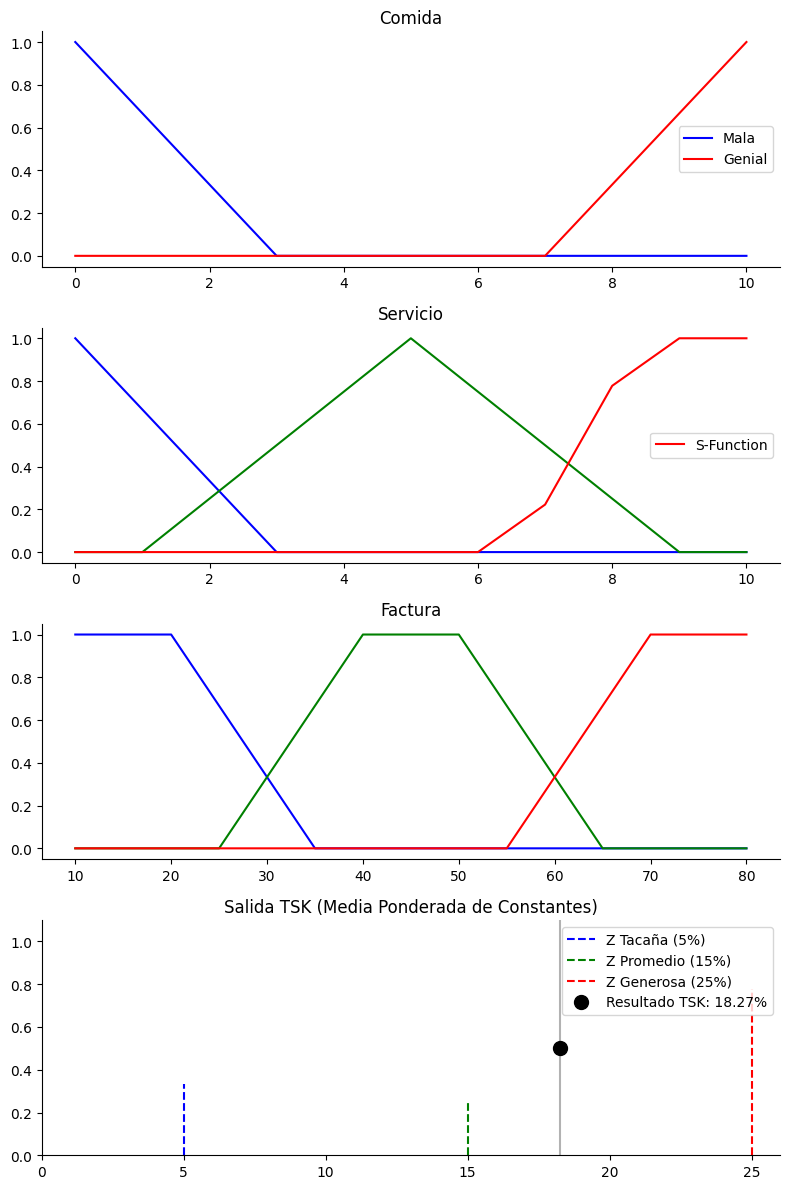

In [15]:
import numpy as np
import skfuzzy as fuzz
import matplotlib.pyplot as plt

# 1. Universos de discurso
x_comida = np.arange(0, 11, 1)
x_servicio = np.arange(0, 11, 1)
x_factura = np.arange(10, 81, 1)
x_propina = np.arange(0, 26, 1) # Solo para escala visual

# 2. Funciones de pertenencia (Entradas)
mala = fuzz.trimf(x_comida, [0, 0, 3])
genial = fuzz.trimf(x_comida, [7, 10, 10])

deficiente = fuzz.trimf(x_servicio, [0, 0, 3])
aceptable = fuzz.trimf(x_servicio, [1, 5, 9])
increible = fuzz.smf(x_servicio, 6, 9)

barata = fuzz.trapmf(x_factura, [10, 10, 20, 35])
normal = fuzz.trapmf(x_factura, [25, 40, 50, 65])
caro = fuzz.trapmf(x_factura, [55, 70, 80, 80])

# --- CONSECUENTES TSK (Valores constantes) ---
z_tacana = 5
z_promedio = 15
z_generosa = 25

# 3. Valores del cliente
p_comida = 2
p_servicio = 8
p_factura = 30

# 4. Fuzzificación
c_mala = fuzz.interp_membership(x_comida, mala, p_comida)
c_genial = fuzz.interp_membership(x_comida, genial, p_comida)
s_deficiente = fuzz.interp_membership(x_servicio, deficiente, p_servicio)
s_aceptable = fuzz.interp_membership(x_servicio, aceptable, p_servicio)
s_increible = fuzz.interp_membership(x_servicio, increible, p_servicio)
f_barata = fuzz.interp_membership(x_factura, barata, p_factura)
f_normal = fuzz.interp_membership(x_factura, normal, p_factura)
f_caro = fuzz.interp_membership(x_factura, caro, p_factura)

# 5. Aplicación de reglas (Pesos w_i)
w1 = np.fmax(s_increible, np.fmax(c_genial, f_barata)) # Generosa
w2 = np.fmin(s_aceptable, f_normal)                    # Promedio
w3 = np.fmax(s_deficiente, c_mala)                    # Tacaña
w4 = f_caro                                           # Tacaña

# 6. Defuzzificación TSK (Media ponderada)
numerador = (w1 * z_generosa) + (w2 * z_promedio) + (w3 * z_tacana) + (w4 * z_tacana)
denominador = w1 + w2 + w3 + w4
propina_final = numerador / denominador if denominador != 0 else 0

# 7. Visualización
fig, (ax0, ax1, ax2, ax3) = plt.subplots(nrows=4, figsize=(8, 12))

# Gráficas de entrada (Iguales a Mamdani)
ax0.plot(x_comida, mala, 'b', label='Mala'); ax0.plot(x_comida, genial, 'r', label='Genial')
ax0.set_title('Comida'); ax0.legend()

ax1.plot(x_servicio, deficiente, 'b'); ax1.plot(x_servicio, aceptable, 'g'); ax1.plot(x_servicio, increible, 'r', label='S-Function')
ax1.set_title('Servicio'); ax1.legend()

ax2.plot(x_factura, barata, 'b'); ax2.plot(x_factura, normal, 'g'); ax2.plot(x_factura, caro, 'r')
ax2.set_title('Factura')

# --- GRÁFICA DE SALIDA TSK ---
# Representamos los consecuentes como líneas verticales (Singletons)
ax3.vlines(z_tacana, 0, max(w3, w4), colors='b', linestyles='dashed', label='Z Tacaña (5%)')
ax3.vlines(z_promedio, 0, w2, colors='g', linestyles='dashed', label='Z Promedio (15%)')
ax3.vlines(z_generosa, 0, w1, colors='r', linestyles='dashed', label='Z Generosa (25%)')

# El resultado final es un punto destacado
ax3.plot(propina_final, 0.5, 'ko', markersize=10, label=f'Resultado TSK: {propina_final:.2f}%')
ax3.axvline(propina_final, color='k', alpha=0.3)

ax3.set_xlim(0, 26)
ax3.set_ylim(0, 1.1)
ax3.set_title('Salida TSK (Media Ponderada de Constantes)')
ax3.legend()

for ax in (ax0, ax1, ax2, ax3):
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.show()

In [16]:
float(propina_final)

18.265306122448983

# Ejercicio 2: Sistema de control difuso para controlar la temperatura del AC

### **Enunciado**
Realizar un sistema de control basado en lógica difusa para controlar el aire acondicionado. Siguiendo la nueva regulación del gobierno, hay que controlar el termostato para intentar evitar que haya subidas y bajadas bruscas, y reducir el gasto e impacto energético.

*Toda la toma de decisiones corre a cargo del experto (tú).*

### **Variables**

*   Entrada: temperatura ambiente (frio, normal, calor)
*   Entrada: humedad (baja, media, alta)
*   Salida: termostato (baja, mantiene, sube)

### **Reglas**

*   R1: SI temperatura es frio ENTONCES termostato sube
*   R2: SI temperatura es normal Y humedad NO es alta ENTONCES termostato se mantiene
*   R3: SI temperatura es calor O humedad es alta ENTONCES termostato baja

**Temperatura Ambiente**

Frio: Máximo en 5°C. Deja de considerarse "frío" al llegar a los 20°C.

Normal: Empieza en 17°C, es totalmente normal entre 19°C y 22°C, y deja de serlo a los 27°C.

Calor: Empieza a notarse a los 25°C y es máximo en el límite de 40°C.

**Humedad**

Baja: Aire muy seco. Deja de ser "baja" al superar el 40%. (Empieza en el 10%)

Media: El rango de confort ideal está entre el 50% y el 70% de humedad.

Alta: Sensación de bochorno. Máxima pertenencia al llegar al 95%.

**Acción del Termostato (salida)** Aquí es donde aplicas la suavidad para cumplir con la regulación de eficiencia energética.

Baja: Una campana centrada en 15°C. El "4" es el ancho y el "6" la pendiente. Esto le dice al sistema que, si hay que bajar, apunte agresivamente hacia el extremo inferior pero de forma curva.

Mantiene: Una curva de Gauss centrada exactamente en los 23°C (punto de confort estándar) con una desviación de 2. Es la función más estable para evitar que el compresor del aire se encienda y apague constantemente.

Sube: Una campana centrada en los 35°C. Al estar centrada en el límite superior, garantiza que cuando el sistema necesite calentar, lo haga siguiendo una transición suave y no un salto lineal.

0.2


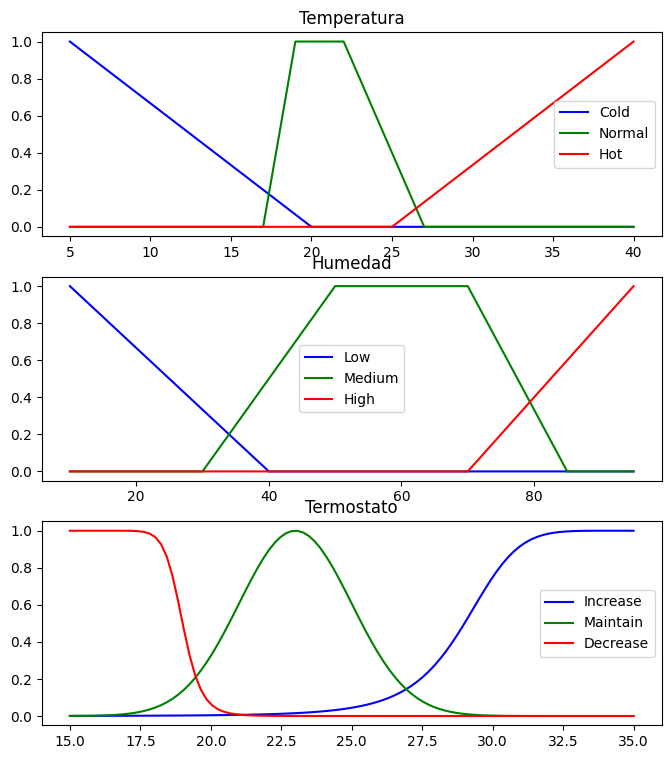

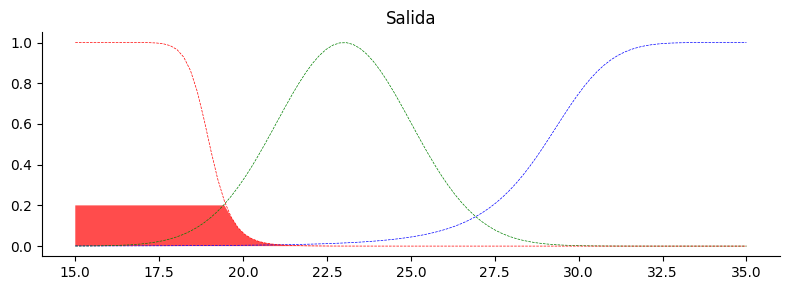

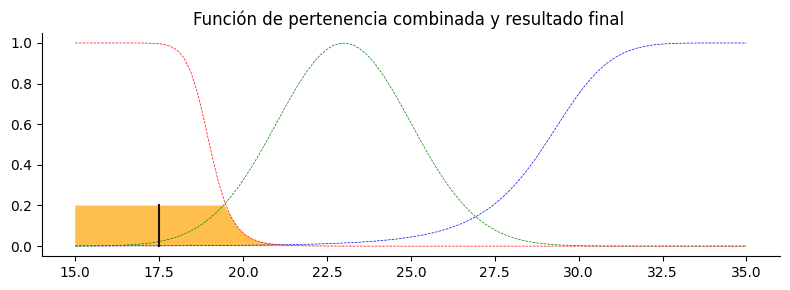

In [17]:
import numpy as np
import skfuzzy as fuzz
import matplotlib.pyplot as plt

# Universal variables
x_temp = np.arange(5, 41, 1)
x_humidity = np.arange(10, 96, 1)
x_thermostat = np.linspace(15, 35, 100)


# Temperature membership functions
cold = fuzz.trimf(x_temp, [5, 5, 20])
normal = fuzz.trapmf(x_temp, [17, 19, 22, 27])
hot = fuzz.trimf(x_temp, [25, 40, 40])

# Humidity membership functions
low = fuzz.trimf(x_humidity, [10, 10, 40])
medium = fuzz.trapmf(x_humidity, [30, 50, 70, 85])
high = fuzz.trimf(x_humidity, [70, 95, 95])

decrease = fuzz.gbellmf(x_thermostat, 4, 6, 15)
maintain = fuzz.gaussmf(x_thermostat, 23, 2)
increase = fuzz.gbellmf(x_thermostat, 6, 3, 35)

# Visualization of universes and membership functions
fig, (ax0, ax1, ax2) = plt.subplots(nrows=3, figsize=(8, 9))

ax0.plot(x_temp, cold, 'b', linewidth=1.5, label='Cold')
ax0.plot(x_temp, normal, 'g', linewidth=1.5, label='Normal')
ax0.plot(x_temp, hot, 'r', linewidth=1.5, label='Hot')
ax0.set_title('Temperatura')
ax0.legend()

ax1.plot(x_humidity, low, 'b', linewidth=1.5, label='Low')
ax1.plot(x_humidity, medium, 'g', linewidth=1.5, label='Medium')
ax1.plot(x_humidity, high, 'r', linewidth=1.5, label='High')
ax1.set_title('Humedad')
ax1.legend()

ax2.plot(x_thermostat, increase, 'b', linewidth=1.5, label='Increase')
ax2.plot(x_thermostat, maintain, 'g', linewidth=1.5, label='Maintain')
ax2.plot(x_thermostat, decrease, 'r', linewidth=1.5, label='Decrease')
ax2.set_title('Termostato')
ax2.legend()

p_temperature = 27
p_humidity = 75

cold_temp = fuzz.interp_membership(x_temp, cold, p_temperature)
normal_temp = fuzz.interp_membership(x_temp, normal, p_temperature)
hot_temp = fuzz.interp_membership(x_temp, hot, p_temperature)

low_humidity = fuzz.interp_membership(x_humidity, low, p_humidity)
medium_humidity = fuzz.interp_membership(x_humidity, medium, p_humidity)
high_humidity = fuzz.interp_membership(x_humidity, high, p_humidity)

# Rule 1: Temperature is cold -> Thermostat increases
activation_increase = cold_temp

# Rule 2: Temperature is normal AND humidity is NOT high -> Thermostat maintains
activation_maintain = np.fmin(normal_temp, 1 - high_humidity)

# Rule 3: Temperature is hot OR humidity is high -> Thermostat decreases
activation_decrease = np.fmax(hot_temp, high_humidity)

# Apply the clipping to output membership functions based on rule activations
activated_increase = np.fmin(activation_increase, increase)
activated_maintain = np.fmin(activation_maintain, maintain)
activated_decrease = np.fmin(activation_decrease, decrease)


noTemp = np.zeros_like(x_thermostat)

# Visualization of the membership functions of the 3 trimmed rules
fig, ax0 = plt.subplots(figsize=(8, 3))

ax0.fill_between(x_thermostat, noTemp, activated_increase, facecolor='b', alpha=0.7)
ax0.plot(x_thermostat, increase, 'b', linewidth=0.5, linestyle='--', )
ax0.fill_between(x_thermostat, noTemp, activated_maintain, facecolor='g', alpha=0.7)
ax0.plot(x_thermostat, maintain, 'g', linewidth=0.5, linestyle='--')
ax0.fill_between(x_thermostat, noTemp, activated_decrease, facecolor='r', alpha=0.7)
ax0.plot(x_thermostat, decrease, 'r', linewidth=0.5, linestyle='--')
ax0.set_title('Salida')

for ax in (ax0,):
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.get_xaxis().tick_bottom()
    ax.get_yaxis().tick_left()

plt.tight_layout()

"""
Agregación de salidas
------------------------------------------------
"""

agregation = np.fmax(activated_increase, np.fmax(activated_maintain, activated_decrease))

"""
Defuzzificación
---------------
Usamos el centroide
-------------------------------------------------
"""

# Centroid defuzzification
# final_decision = fuzz.defuzz(x_thermostat, agregation, 'mom') #Final result
final_decision = fuzz.defuzz(x_thermostat, agregation, 'centroid')
f_thermostat = fuzz.interp_membership(x_thermostat, agregation, final_decision)

print(f_thermostat)

# Displaying the aggregated membership functions with the final result
fig, ax0 = plt.subplots(figsize=(8, 3))

ax0.plot(x_thermostat, increase, 'b', linewidth=0.5, linestyle='--', )
ax0.plot(x_thermostat, maintain, 'g', linewidth=0.5, linestyle='--')
ax0.plot(x_thermostat, decrease, 'r', linewidth=0.5, linestyle='--')
ax0.fill_between(x_thermostat, noTemp, agregation, facecolor='Orange', alpha=0.7)
ax0.plot([final_decision, final_decision], [0, f_thermostat], 'k', linewidth=1.5, alpha=0.9)
ax0.set_title('Función de pertenencia combinada y resultado final ')


for ax in (ax0,):
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.get_xaxis().tick_bottom()
    ax.get_yaxis().tick_left()

plt.tight_layout()

In [18]:
float(final_decision)

17.497213491309918

# Ejercicio 3: Sistema de control difuso para conocer el riesgo de tener cáncer de pulmón

 **Enunciado**
Realizar un sistema de control basado en lógica difusa para analizar el riesgo de padecer cáncer de pulmón en base a unos datos.


NOTA: Las reglas y variables se muestran en la siguiente tabla (naranja significa operador Y y rosa significa OR):

![](ej3.jpg)


In [19]:
import numpy as np
import skfuzzy as fuzz
import matplotlib.pyplot as plt

# Universal variables
x_age = np.arange(10, 101, 1)
x_genotype = np.arange(0, 11, 1)
x_tobaco = np.arange(0, 41, 1)
x_weight = np.arange(25, 121, 1)
x_feeding = np.arange(0, 11, 1)
x_risk = np.arange(0, 101, 1)

# Age membership functions
joven = fuzz.trimf(x_age, [0, 0, 25])
adulto = fuzz.trimf(x_age, [20, 40, 65])
mayor = fuzz.trimf(x_age, [60, 100, 100])

# Genotype membership functions
baja = fuzz.trimf(x_genotype, [0, 0, 4])
media = fuzz.trimf(x_genotype, [3, 6, 8])
alta = fuzz.trimf(x_genotype, [7, 10, 10])

# Tobaco membership functions
ninguno = fuzz.trimf(x_tobaco, [0, 0, 3])
ocasional = fuzz.trimf(x_tobaco, [2, 5, 7])
frecuente = fuzz.trimf(x_tobaco, [5, 10, 25])
empedernido = fuzz.trimf(x_tobaco, [20, 40, 40])

# Weight membership functions
muydelgado = fuzz.trimf(x_weight, [25, 25, 40])
delgado = fuzz.trimf(x_weight, [40, 60, 80])
normal = fuzz.trimf(x_weight, [40, 70, 95])
sobrepeso = fuzz.trimf(x_weight, [90, 120, 120])

# Feeding membership functios
desequilibrada = fuzz.trimf(x_feeding, [0, 0, 4])
incompleta = fuzz.trimf(x_feeding, [2, 6, 8])
equilibrada = fuzz.trimf(x_feeding, [7, 10, 10])

# Risk membership functions
rmuybajo = fuzz.trimf(x_risk, [0, 0, 7])
rbajo = fuzz.trimf(x_risk, [5, 13, 20])
rmedio = fuzz.trimf(x_risk, [18, 30, 45])
ralto = fuzz.trimf(x_risk, [40, 60, 85])
rextremo = fuzz.trimf(x_risk, [80, 100, 100])

p_age = 45
p_genotype = 3
p_tobaco = 30
p_weight = 85
p_feeding = 3

joven_age = fuzz.interp_membership(x_age, joven, p_age)
adulto_age = fuzz.interp_membership(x_age, adulto, p_age)
mayor_age = fuzz.interp_membership(x_age, mayor, p_age)

baja_gen = fuzz.interp_membership(x_genotype, baja, p_genotype)
media_gen = fuzz.interp_membership(x_genotype, media, p_genotype)
alta_gen = fuzz.interp_membership(x_genotype, alta, p_genotype)

ningun_tob = fuzz.interp_membership(x_tobaco, ninguno, p_tobaco)
ocasional_tob = fuzz.interp_membership(x_tobaco, ocasional, p_tobaco)
frecuente_tob = fuzz.interp_membership(x_tobaco, frecuente, p_tobaco)
empedernido_tob = fuzz.interp_membership(x_tobaco, empedernido, p_tobaco)

muydelgado_weight = fuzz.interp_membership(x_weight, muydelgado, p_weight)
delgado_weight = fuzz.interp_membership(x_weight, delgado, p_weight)
normal_weight = fuzz.interp_membership(x_weight, normal, p_weight)
sobrepeso_weight = fuzz.interp_membership(x_weight, sobrepeso, p_weight)

desequilibrada_feed = fuzz.interp_membership(x_feeding, desequilibrada, p_feeding)
incompleta_feed = fuzz.interp_membership(x_feeding, incompleta, p_feeding)
equilibrada_feed = fuzz.interp_membership(x_feeding, equilibrada, p_feeding)

# Rule R1
aplication_R1 = np.fmin(np.fmin(np.fmin(joven_age, baja_gen), np.fmin(ningun_tob, normal_weight)), equilibrada_feed)
activation_rmuybajo = np.fmin(aplication_R1, rmuybajo)

# Rule R2
aplication_R2 = np.fmin(np.fmin(adulto_age, baja_gen), ningun_tob)
activation_rmuybajo2 = np.fmin(aplication_R2, rmuybajo)

# Rule R3
aplication_R3 = np.fmin(joven_age, media_gen)
activation_rbajo = np.fmin(aplication_R3, rbajo)

# Rule R4
aplication_R4 = np.fmin(np.fmin(adulto_age, baja_gen), np.fmin(ningun_tob, sobrepeso_weight))
activation_rbajo2 = np.fmin(aplication_R4, rbajo)

# Rule R5
aplication_R5 = np.fmax(mayor_age, media_gen)
activation_rmedio = np.fmin(aplication_R5, rmedio)

# Rule R6
aplication_R6 = np.fmin(np.fmin(np.fmin(joven_age, alta_gen), np.fmin(empedernido_tob, muydelgado_weight)), desequilibrada_feed)
activation_rmedio2 = np.fmin(aplication_R6, rmedio)

# Rule R7
aplication_R7 = np.fmin(np.fmin(adulto_age, media_gen), np.fmin(frecuente_tob, sobrepeso_weight))
activation_ralto = np.fmin(aplication_R7, ralto)

# Rule R8
aplication_R8 = np.fmin(np.fmin(np.fmin(mayor_age, alta_gen), np.fmin(ningun_tob, normal_weight)), incompleta_feed)
activation_ralto2 = np.fmin(aplication_R8, ralto)

# Rule R9
aplication_R9 = np.fmax(np.fmax(adulto_age, alta_gen), empedernido_tob)
activation_rextremo = np.fmin(aplication_R9, rextremo)

# Rule R10
aplication_R10 = np.fmin(np.fmin(np.fmin(mayor_age, baja_gen), np.fmin(frecuente_tob, muydelgado_weight)), desequilibrada_feed)
activation_rextremo2 = np.fmin(aplication_R10, rextremo)

"""
Agregación de salidas
------------------------------------------------
"""


# Aggregating all the rules by taking the maximum membership values
agregation12 = np.fmax(activation_rmuybajo, activation_rmuybajo2)
agregation34 = np.fmax(activation_rbajo, activation_rbajo2)
agregation56 = np.fmax(activation_rmedio, activation_rmedio2)
agregation78 = np.fmax(activation_ralto, activation_ralto2)
agregation910 = np.fmax(activation_rextremo, activation_rextremo2)

agregation1234 = np.fmax(agregation12, agregation34)
agregation5678 = np.fmax(agregation56, agregation78)

agregation12345678 = np.fmax(agregation1234, agregation5678)

final_agregation = np.fmax(agregation910, agregation12345678)

# Defuzzificación
final_risk = fuzz.defuzz(x_risk, final_agregation, 'centroid')

print(f"Riesgo: {final_risk} %")



Riesgo: 93.1111111111111 %


# Ejercicio 1: Sistema Difuso para el Control de Riego Automático
Contexto:
Un agricultor tecnológico desea automatizar el riego de sus cultivos de tomates. Para ello, utiliza un sensor que mide la Humedad del Suelo y otro que mide la Temperatura Ambiental. El sistema debe decidir el Tiempo de Riego (en minutos) óptimo para mantener las plantas sanas sin desperdiciar agua.

1. Definición de Variables

Humedad del Suelo: Rango [0, 100] %.

Seco: [0, 0, 40]

Húmedo: [30, 50, 70]

Saturado: [60, 100, 100]

Temperatura: Rango [0, 50] °C.

Frío: [0, 0, 20]

Templado: [15, 25, 35]

Caluroso: [30, 50, 50]

Tiempo de Riego (Salida): Rango [0, 60] minutos.

Corto: [0, 0, 20]

Medio: [15, 30, 45]

Largo: [40, 60, 60]

2. Base de Reglas

Implementa la lógica del sistema basada en las siguientes reglas:

R1: SI la humedad es Seco O la temperatura es Caluroso, ENTONCES el riego es Largo.

R2: SI la humedad es Húmedo Y la temperatura es Templado, ENTONCES el riego es Medio.

R3: SI la humedad es Saturado, ENTONCES el riego es Corto.

1. Programación: Traducir las definiciones de variables y reglas al código usando la librería skfuzzy.

2. Evaluación: Calcula el tiempo de riego exacto si el sensor marca una Humedad del 35% y una Temperatura de 32°C.

3. Análisis: * Visualiza las funciones de pertenencia iniciales.

Muestra el área resultante de la agregación de reglas para el caso dado.

Obtén el valor final (defuzzificación) usando el método del centroide.

Tiempo de Riego óptimo: 35.14 minutos


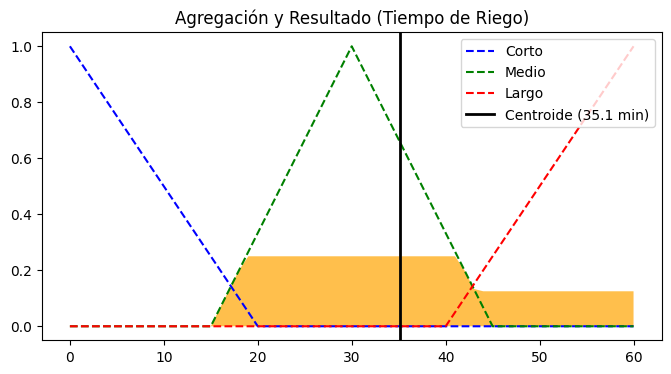

In [20]:
import numpy as np
import skfuzzy as fuzz
import matplotlib.pyplot as plt

# 1. Variables y Universos
x_humedad = np.arange(0, 101, 1)
x_temp = np.arange(0, 51, 1)
x_riego = np.arange(0, 61, 1)

# Funciones de pertenencia
h_seco = fuzz.trimf(x_humedad, [0, 0, 40])
h_humedo = fuzz.trimf(x_humedad, [30, 50, 70])
h_saturado = fuzz.trimf(x_humedad, [60, 100, 100])

t_frio = fuzz.trimf(x_temp, [0, 0, 20])
t_templado = fuzz.trimf(x_temp, [15, 25, 35])
t_caluroso = fuzz.trimf(x_temp, [30, 50, 50])

r_corto = fuzz.trimf(x_riego, [0, 0, 20])
r_medio = fuzz.trimf(x_riego, [15, 30, 45])
r_largo = fuzz.trimf(x_riego, [40, 60, 60])

# 2. Valores del caso práctico
p_humedad = 35
p_temp = 32

# Fuzzificación
val_h_seco = fuzz.interp_membership(x_humedad, h_seco, p_humedad)
val_h_humedo = fuzz.interp_membership(x_humedad, h_humedo, p_humedad)
val_h_saturado = fuzz.interp_membership(x_humedad, h_saturado, p_humedad)

val_t_frio = fuzz.interp_membership(x_temp, t_frio, p_temp)
val_t_templado = fuzz.interp_membership(x_temp, t_templado, p_temp)
val_t_caluroso = fuzz.interp_membership(x_temp, t_caluroso, p_temp)

# 3. Base de Reglas
# R1: Seco OR Caluroso -> Largo
r1_act = np.fmax(val_h_seco, val_t_caluroso)
act_largo = np.fmin(r1_act, r_largo)

# R2: Húmedo AND Templado -> Medio
r2_act = np.fmin(val_h_humedo, val_t_templado)
act_medio = np.fmin(r2_act, r_medio)

# R3: Saturado -> Corto
act_corto = np.fmin(val_h_saturado, r_corto)

# 4. Agregación y Defuzzificación
agregacion = np.fmax(act_corto, np.fmax(act_medio, act_largo))
tiempo_riego = fuzz.defuzz(x_riego, agregacion, 'centroid')

print(f"Tiempo de Riego óptimo: {tiempo_riego:.2f} minutos")

# 5. Visualización
fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(x_riego, r_corto, 'b', linestyle='--', label='Corto')
ax.plot(x_riego, r_medio, 'g', linestyle='--', label='Medio')
ax.plot(x_riego, r_largo, 'r', linestyle='--', label='Largo')
ax.fill_between(x_riego, 0, agregacion, facecolor='Orange', alpha=0.7)
ax.axvline(tiempo_riego, color='k', linewidth=2, label=f'Centroide ({tiempo_riego:.1f} min)')
ax.set_title('Agregación y Resultado (Tiempo de Riego)')
ax.legend()
plt.show()

# Ejercicio 2: Sistema de Frenado Inteligente (ABS Diferencial)
Contexto:
Se desea diseñar un sistema de asistencia al frenado para un vehículo autónomo. El sistema debe decidir la Presión de Frenado basándose en la Distancia al Obstáculo y la Velocidad Actual del vehículo.
1. Definición de Variables
Distancia al Obstáculo: Rango [0, 100] metros.

Crítica: [0, 0, 30] (Triangular)

Segura: [20, 50, 80] (Triangular)

Lejos: [70, 100, 100] (Triangular)

Velocidad: Rango [0, 120] km/h.

Lenta: [0, 0, 50] (Triangular)

Media: [40, 60, 80] (Triangular)

Rápida: [70, 120, 120] (Triangular)

Presión de Frenado (Salida): Rango [0, 100] %.

Suave:[0, 0, 20, 40] (Trapezoidal: fuzz.trapmf)

Fuerte: [30, 50, 70, 90] (Trapezoidal: fuzz.trapmf)

Emergencia: [80, 90, 100, 100] (Trapezoidal: fuzz.trapmf)

2. Base de Reglas
R1: SI la distancia es Crítica Y la velocidad es Rápida, ENTONCES la presión es Emergencia.

R2: SI la distancia es Segura Y la velocidad es Media, ENTONCES la presión es Fuerte.

R3: SI la distancia es Lejos O la velocidad es Lenta, ENTONCES la presión es Suave.

1. Programación: Define los universos de discurso y las funciones de pertenencia. Fíjate que para la salida debes usar fuzz.trapmf(universo, [a, b, c, d]).

2. Cálculo: Determina la presión de frenado para un vehículo que va a 95 km/h y tiene un obstáculo a 25 metros.

3. Visualización: Genera el gráfico de la función agregada y marca la línea del centroide.

Presión de Frenado resultante: 90.44%


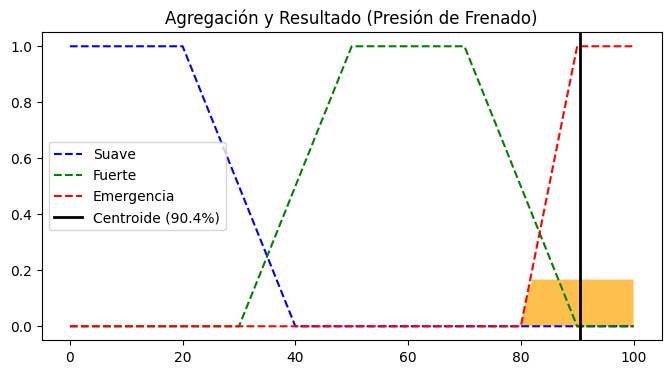

In [21]:
import numpy as np
import skfuzzy as fuzz
import matplotlib.pyplot as plt

# 1. Variables y Universos
x_dist = np.arange(0, 101, 1)
x_vel = np.arange(0, 121, 1)
x_presion = np.arange(0, 101, 1)

# Funciones de pertenencia (Entradas triangulares, Salidas trapezoidales)
d_critica = fuzz.trimf(x_dist, [0, 0, 30])
d_segura = fuzz.trimf(x_dist, [20, 50, 80])
d_lejos = fuzz.trimf(x_dist, [70, 100, 100])

v_lenta = fuzz.trimf(x_vel, [0, 0, 50])
v_media = fuzz.trimf(x_vel, [40, 60, 80])
v_rapida = fuzz.trimf(x_vel, [70, 120, 120])

p_suave = fuzz.trapmf(x_presion, [0, 0, 20, 40])
p_fuerte = fuzz.trapmf(x_presion, [30, 50, 70, 90])
p_emergencia = fuzz.trapmf(x_presion, [80, 90, 100, 100])

# 2. Valores del caso práctico
p_distancia = 25
p_velocidad = 95

# Fuzzificación
val_d_critica = fuzz.interp_membership(x_dist, d_critica, p_distancia)
val_d_segura = fuzz.interp_membership(x_dist, d_segura, p_distancia)
val_d_lejos = fuzz.interp_membership(x_dist, d_lejos, p_distancia)

val_v_lenta = fuzz.interp_membership(x_vel, v_lenta, p_velocidad)
val_v_media = fuzz.interp_membership(x_vel, v_media, p_velocidad)
val_v_rapida = fuzz.interp_membership(x_vel, v_rapida, p_velocidad)

# 3. Base de Reglas
# R1: Crítica AND Rápida -> Emergencia
r1_act = np.fmin(val_d_critica, val_v_rapida)
act_emergencia = np.fmin(r1_act, p_emergencia)

# R2: Segura AND Media -> Fuerte
r2_act = np.fmin(val_d_segura, val_v_media)
act_fuerte = np.fmin(r2_act, p_fuerte)

# R3: Lejos OR Lenta -> Suave
r3_act = np.fmax(val_d_lejos, val_v_lenta)
act_suave = np.fmin(r3_act, p_suave)

# 4. Agregación y Defuzzificación
agregacion = np.fmax(act_suave, np.fmax(act_fuerte, act_emergencia))
presion_final = fuzz.defuzz(x_presion, agregacion, 'centroid')

print(f"Presión de Frenado resultante: {presion_final:.2f}%")

# 5. Visualización
fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(x_presion, p_suave, 'b', linestyle='--', label='Suave')
ax.plot(x_presion, p_fuerte, 'g', linestyle='--', label='Fuerte')
ax.plot(x_presion, p_emergencia, 'r', linestyle='--', label='Emergencia')
ax.fill_between(x_presion, 0, agregacion, facecolor='Orange', alpha=0.7)
ax.axvline(presion_final, color='k', linewidth=2, label=f'Centroide ({presion_final:.1f}%)')
ax.set_title('Agregación y Resultado (Presión de Frenado)')
ax.legend()
plt.show()